# USEFUL PLOTS

/Users/yerik/_apple_lib/_b_envs/2ms_env/lib/python3.11/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


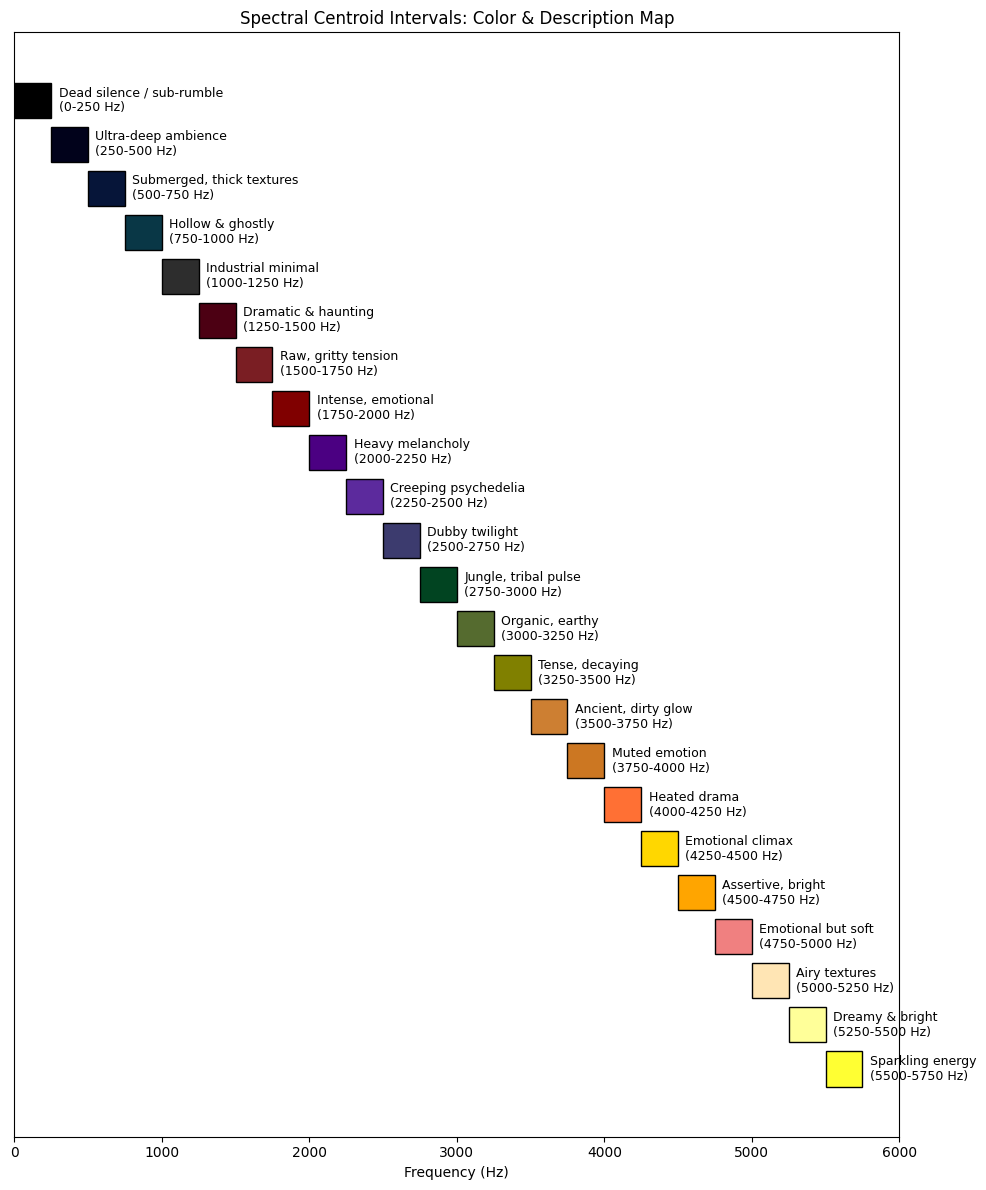

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define the intervals and their colors and descriptions
spectral_centroid_intervals_1504 = [
    (0, 250, '#000000', 'Dead silence / sub-rumble'),
    (250, 500, '#01021B', 'Ultra-deep ambience'),
    (500, 750, '#061539', 'Submerged, thick textures'),
    (750, 1000, '#093746', 'Hollow & ghostly'),
    (1000, 1250, '#2D2D2D', 'Industrial minimal'),
    (1250, 1500, '#4C0013', 'Dramatic & haunting'),
    (1500, 1750, '#7A1E23', 'Raw, gritty tension'),
    (1750, 2000, '#800000', 'Intense, emotional'),
    (2000, 2250, '#4B0082', 'Heavy melancholy'),
    (2250, 2500, '#5C2A9D', 'Creeping psychedelia'),
    (2500, 2750, '#3C3B6E', 'Dubby twilight'),
    (2750, 3000, '#014421', 'Jungle, tribal pulse'),
    (3000, 3250, '#556B2F', 'Organic, earthy'),
    (3250, 3500, '#808000', 'Tense, decaying'),
    (3500, 3750, '#CD7F32', 'Ancient, dirty glow'),
    (3750, 4000, '#CC7722', 'Muted emotion'),
    (4000, 4250, '#FF7034', 'Heated drama'),
    (4250, 4500, '#FFD700', 'Emotional climax'),
    (4500, 4750, '#FFA500', 'Assertive, bright'),
    (4750, 5000, '#F08080', 'Emotional but soft'),
    (5000, 5250, '#FFE5B4', 'Airy textures'),
    (5250, 5500, '#FFFF99', 'Dreamy & bright'),
    (5500, 5750, '#FFFF33', 'Sparkling energy'),
    (5750, float('inf'), '#FFFFFF', 'Harsh, clinical, hyper-bright')
]

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(spectral_centroid_intervals_1504))

# Plot colored bars
for i, (start, end, color, label) in enumerate(spectral_centroid_intervals_1504):
    ax.barh(i, end - start, left=start, color=color, edgecolor='black')
    ax.text(end + 50, i, f'{label}\n({start}-{int(end) if end != float("inf") else "∞"} Hz)',
            va='center', fontsize=9)

# Styling
ax.set_yticks([])
ax.set_xlabel('Frequency (Hz)')
ax.set_title('Spectral Centroid Intervals: Color & Description Map')
ax.set_xlim(0, 6000)
ax.invert_yaxis()
plt.tight_layout()

plt.show()


# flac to AIFF

### better one 

In [11]:
# -----######-----###### CORE IMPORTABLE FUNCTION (Batch FLAC/WAV → AIFF for CDJs w/ Tags + Broken Check) -----######-----###### #
import subprocess, shutil, sys
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

from mutagen import File
from mutagen.aiff import AIFF
from mutagen.id3 import (
    ID3, ID3NoHeaderError, ID3BadUnsynchData,
    TIT2, TPE1, TPE2, TALB, TCON, TDRC, TRCK, TPOS, COMM, TBPM, TKEY,
    TPUB, TSRC, TPE3, TCOM, TENC, APIC, CTOC, CHAP
)


# -------------------- helpers -------------------- #
def _safe_get_first(d, key):
    if d is None: return None
    v = d.get(key)
    if v is None: return None
    if isinstance(v, (list, tuple)): 
        return v[0] if v else None
    return v

def _as_int_pair(text):
    if not text: return None, None
    s = str(text)
    if '/' in s:
        a,b = s.split('/',1)
        return (a.strip() or None), (b.strip() or None)
    return (s.strip() or None), None

def _ensure_id3(aiff_path):
    a = AIFF(aiff_path)
    if a.tags is None:
        a.add_tags()
    return a

def _copy_id3_frames(src_id3, dst_id3):
    # Copy common frames + chapters/artwork; ignore exotica that fail to serialize.
    for frame in src_id3.values():
        try:
            if isinstance(frame, APIC):
                dst_id3.add(APIC(encoding=frame.encoding, mime=frame.mime, type=frame.type, desc=frame.desc, data=frame.data))
            elif isinstance(frame, COMM):
                dst_id3.add(COMM(encoding=frame.encoding, lang=frame.lang, desc=frame.desc, text=frame.text))
            elif isinstance(frame, (TIT2, TPE1, TPE2, TALB, TCON, TDRC, TRCK, TPOS, TBPM, TKEY, TPUB, TSRC, TPE3, TCOM, TENC)):
                dst_id3.add(type(frame)(encoding=frame.encoding, text=frame.text))
            elif isinstance(frame, (CTOC, CHAP)):
                dst_id3.add(frame)
            else:
                dst_id3.add(frame)
        except Exception:
            pass

def _map_vorbis_to_id3(vtags, dst_id3, pictures=None):
    title   = _safe_get_first(vtags, "title")
    artist  = _safe_get_first(vtags, "artist")
    album   = _safe_get_first(vtags, "album")
    albumartist = _safe_get_first(vtags, "albumartist") or _safe_get_first(vtags, "album artist")
    genre   = _safe_get_first(vtags, "genre")
    date    = _safe_get_first(vtags, "date") or _safe_get_first(vtags, "year")
    comment = _safe_get_first(vtags, "comment") or _safe_get_first(vtags, "description")
    bpm     = _safe_get_first(vtags, "bpm")
    key_    = _safe_get_first(vtags, "initialkey") or _safe_get_first(vtags, "key")
    label   = _safe_get_first(vtags, "label") or _safe_get_first(vtags, "publisher")
    isrc    = _safe_get_first(vtags, "isrc")
    remixer = _safe_get_first(vtags, "remixer")
    composer= _safe_get_first(vtags, "composer")
    encoder = _safe_get_first(vtags, "encoder") or _safe_get_first(vtags, "encodedby") or _safe_get_first(vtags, "encoded_by")
    trk     = _safe_get_first(vtags, "tracknumber")
    dsk     = _safe_get_first(vtags, "discnumber")

    if title:   dst_id3.add(TIT2(encoding=3, text=str(title)))
    if artist:  dst_id3.add(TPE1(encoding=3, text=str(artist)))
    if album:   dst_id3.add(TALB(encoding=3, text=str(album)))
    if albumartist: dst_id3.add(TPE2(encoding=3, text=str(albumartist)))
    if genre:   dst_id3.add(TCON(encoding=3, text=str(genre)))
    if date:    dst_id3.add(TDRC(encoding=3, text=str(date)))
    if comment: dst_id3.add(COMM(encoding=3, lang="eng", desc="", text=str(comment)))
    if bpm:     dst_id3.add(TBPM(encoding=3, text=str(bpm)))
    if key_:    dst_id3.add(TKEY(encoding=3, text=str(key_)))
    if label:   dst_id3.add(TPUB(encoding=3, text=str(label)))
    if isrc:    dst_id3.add(TSRC(encoding=3, text=str(isrc)))
    if remixer: dst_id3.add(TPE3(encoding=3, text=str(remixer)))
    if composer:dst_id3.add(TCOM(encoding=3, text=str(composer)))
    if encoder: dst_id3.add(TENC(encoding=3, text=str(encoder)))

    if trk:
        n, d = _as_int_pair(trk)
        if n or d:
            dst_id3.add(TRCK(encoding=3, text=[f"{n or ''}/{d or ''}".strip('/')]))
    if dsk:
        n, d = _as_int_pair(dsk)
        if n or d:
            dst_id3.add(TPOS(encoding=3, text=[f"{n or ''}/{d or ''}".strip('/')]))

    if pictures:
        for pic in pictures:
            try:
                dst_id3.add(APIC(encoding=3, mime=pic.mime or "image/jpeg", type=3, desc=u"", data=pic.data))
            except Exception:
                pass

def _copy_all_tags_to_aiff(src_path, aiff_path):
    """
    After encoding, write a clean ID3 tag set into the AIFF.
    - If source has ID3: copy frames.
    - Else: map Vorbis/WAV INFO to ID3; copy artwork where possible.
    """
    src = File(src_path)
    dst_aiff = _ensure_id3(aiff_path)
    dst_id3 = dst_aiff.tags  # mutagen.id3.ID3

    if src is None:
        dst_aiff.save()
        return

    # Direct ID3 → ID3
    try:
        src_id3 = getattr(src, "tags", None)
        if isinstance(src_id3, ID3) or (src_id3 and any(k.startswith("T") or k in ("APIC","COMM") for k in src_id3.keys())):
            try:
                _copy_id3_frames(src_id3, dst_id3)
                dst_aiff.save()
                return
            except Exception:
                pass
    except Exception:
        pass

    # Vorbis/FLAC or generic tags → ID3
    vtags = getattr(src, "tags", None)
    pictures = []
    # Try FLAC pictures
    try:
        if hasattr(src, "pictures"):
            pictures = src.pictures or []
        elif hasattr(src, "tags") and "METADATA_BLOCK_PICTURE" in src.tags:
            # Some FLACs expose pictures via this key (base64) — skipped for simplicity
            pictures = []
    except Exception:
        pictures = []

    try:
        _map_vorbis_to_id3(vtags or {}, dst_id3, pictures=pictures)
    except Exception:
        pass

    dst_aiff.save()

def _verify_aiff_ok(aiff_path):
    try:
        t = AIFF(aiff_path)
        _ = t.info.length  # raises if broken
        return True, None
    except Exception as e:
        return False, str(e)

# -------------------- per-file converter -------------------- #
def _convert_2008_flacwav_GET_aiff_cdj(file_in, out_dir=None):
    """
    Convert a single FLAC/WAV → AIFF (44.1kHz / 16-bit / stereo), conserve tags & artwork.
    Returns (status, path_out). status in {"ok", "broken", "skipped", "fail"}
    """
    src_path = Path(file_in)
    ext = src_path.suffix.lower()
    if ext in (".aiff", ".aif"):
        return "skipped", None

    if out_dir is None:
        out_dir = src_path.parent
    else:
        out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)

    dst_path = out_dir / (src_path.stem + ".aiff")

    # Encode: strip metadata now; write clean tags after
    cmd = [
        "ffmpeg", "-y", "-i", str(src_path),
        "-ar", "44100", "-ac", "2", "-sample_fmt", "s16",
        "-map_metadata", "-1",
        str(dst_path)
    ]
    p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if p.returncode != 0 or not dst_path.exists():
        return "fail", None

    # Write tags
    try:
        _copy_all_tags_to_aiff(src_path, dst_path)
    except Exception:
        # Non-fatal; still verify audio container
        pass

    # Verify playable
    ok, err = _verify_aiff_ok(dst_path)
    if ok:
        return "ok", dst_path
    else:
        broken_path = dst_path.with_stem(dst_path.stem + "_BROKEN")
        try:
            shutil.move(dst_path, broken_path)
        except Exception:
            pass
        return "broken", broken_path if broken_path.exists() else dst_path

# -------------------- batch (recursive) -------------------- #
def _convert_2008_folder_GET_aiff_cdj_batch(root_folder, out_root=None, audio_extensions=None, dry_run="n"):
    """
    Recursively scan root_folder for FLAC/WAV and convert to AIFF (CDJ-safe).
    - Conserves tags & artwork
    - Marks broken as *_BROKEN.aiff
    - Skips existing AIFF
    - Mirrors folder structure if out_root is provided

    Inputs:
      root_folder: str/Path → folder to scan
      out_root:    optional str/Path → root where AIFFs are written (mirrors structure). Default: alongside source files
      audio_extensions: iterable of extensions to consider (e.g., [".flac",".wav",".aif",".aiff"])
      dry_run: "y" to only list targets (no conversion). "n" (default) to run.

    Returns:
      summary dict {
        'ok': int, 'broken': int, 'skipped': int, 'fail': int,
        'total_scanned': int, 'total_converted': int
      }
    """
    root = Path(root_folder)
    if audio_extensions is None:
        audio_extensions = [".flac", ".FLAC", ".wav", ".WAV", ".aiff", ".AIFF", ".aif", ".AIF"]

    # Collect candidate files (skip macOS junk)
    all_files = [
        p for p in root.rglob("*")
        if p.is_file()
        and not p.name.startswith("._")
        and p.name != ".DS_Store"
        and p.suffix in audio_extensions
    ]

    # Filter to only FLAC/WAV for conversion; AIFF just counted as skipped later
    targets = [p for p in all_files if p.suffix.lower() in (".flac", ".wav")]

    # TQM progress bar
    pbar = tqdm(total=len(targets), desc="TQM • Converting to AIFF (16/44.1/stereo)", unit="file")

    stats = dict(ok=0, broken=0, skipped=0, fail=0)
    for src_path in targets:
        rel = src_path.relative_to(root)
        if out_root:
            out_dir = Path(out_root) / rel.parent
        else:
            out_dir = None

        if dry_run.lower().startswith("y"):
            # Just preview
            pbar.set_postfix_str(f"DRY-RUN → {src_path.name}")
            pbar.update(1)
            continue

        status, outp = _convert_2008_flacwav_GET_aiff_cdj(src_path, out_dir=out_dir)
        if status in stats:
            stats[status] += 1
        else:
            stats["fail"] += 1  # safety

        pbar.set_postfix_str(f"{status.upper()}: {src_path.name}")
        pbar.update(1)

    pbar.close()

    # Account for already-AIFF files encountered (not processed in loop)
    stats["skipped"] += len([p for p in all_files if p.suffix.lower() in (".aif", ".aiff")])

    summary = {
        **stats,
        "total_scanned": len(all_files),
        "total_converted": stats["ok"] + stats["broken"] + stats["fail"]
    }

    # Print compact summary
    stamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(
        f"[{stamp}] Done.\n"
        f" • Scanned: {summary['total_scanned']}\n"
        f" • Converted OK: {summary['ok']}\n"
        f" • Broken: {summary['broken']} (tagged *_BROKEN.aiff)\n"
        f" • Failed: {summary['fail']}\n"
        f" • Skipped (already AIFF): {summary['skipped']}\n"
    )
    return summary


In [12]:
# REQUIRED: Have ffmpeg installed and available in PATH.
# Trial run (replace paths as needed):

# Folder to crawl (recursively)
in_root  = "/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCER/_25_ADD_SINCER"   # ⬅️ your input folder
out_root = None  # or set a mirror output root like "/Users/yerik/Desktop/_AIFF_OUT"

# External extension list (as you prefer to keep it outside functions)
audio_extensions = [".flac", ".FLAC", ".wav", ".WAV", ".aif", ".AIF", ".aiff", ".AIFF"]

# DRY RUN first (preview only; no writes):
# _convert_2008_folder_GET_aiff_cdj_batch(in_root, out_root=out_root, audio_extensions=audio_extensions, dry_run="y")

# REAL RUN:
_convert_2008_folder_GET_aiff_cdj_batch(in_root, out_root=out_root, audio_extensions=audio_extensions, dry_run="n")


TQM • Converting to AIFF (16/44.1/stereo): 100%|█| 1243/1243 [02:25<00:00,  8.56file/s, OK: TRkw_Diamonds_ARkw

[2025-08-29 17:31:09] Done.
 • Scanned: 1279
 • Converted OK: 1243
 • Broken: 0 (tagged *_BROKEN.aiff)
 • Failed: 0
 • Skipped (already AIFF): 36



{'ok': 1243,
 'broken': 0,
 'skipped': 36,
 'fail': 0,
 'total_scanned': 1279,
 'total_converted': 1243}

In [13]:
# -----######-----###### CORE IMPORTABLE FUNCTION (Erase everything but AIFF) -----######-----###### #
import os
from pathlib import Path
from tqdm import tqdm

def _cleanup_2208_keepaiff_GET_removed_files(root_folder, dry_run="n"):
    """
    Recursively erase everything but AIFF (.aiff/.aif) files.
    Skips system junk (.DS_Store, ._*).
    
    Inputs:
      root_folder : str/Path → folder to clean
      dry_run     : "y" = preview only, "n" = actually delete
    
    Returns:
      dict summary with counts
    """
    root = Path(root_folder)

    # Collect all files
    all_files = [p for p in root.rglob("*") if p.is_file()]
    # Keep only those NOT AIFF
    targets = [
        p for p in all_files
        if p.suffix.lower() not in (".aiff", ".aif")
        and not p.name.startswith("._")
        and p.name != ".DS_Store"
    ]

    # Progress bar
    pbar = tqdm(total=len(targets), desc="TQM • Cleaning non-AIFF files", unit="file")

    removed, skipped = 0, 0
    for f in targets:
        if dry_run.lower().startswith("y"):
            pbar.set_postfix_str(f"DRY-RUN: would remove {f.name}")
            skipped += 1
        else:
            try:
                f.unlink()
                removed += 1
                pbar.set_postfix_str(f"Removed {f.name}")
            except Exception as e:
                skipped += 1
                pbar.set_postfix_str(f"⚠️ Skip {f.name}: {e}")
        pbar.update(1)

    pbar.close()

    summary = {
        "total_files": len(all_files),
        "removed": removed,
        "skipped": skipped,
        "kept_aiff": len(all_files) - len(targets),
    }

    print(
        f"Done cleanup.\n"
        f" • Total files scanned: {summary['total_files']}\n"
        f" • Removed: {summary['removed']}\n"
        f" • Skipped (errors/dry-run): {summary['skipped']}\n"
        f" • Kept AIFF: {summary['kept_aiff']}\n"
    )
    return summary


In [14]:
# Example run
folder = "/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCER"

# Preview only (see what would be deleted):
# _cleanup_2208_keepaiff_GET_removed_files(folder, dry_run="y")

# Actual delete:
_cleanup_2208_keepaiff_GET_removed_files(folder, dry_run="n")


TQM • Cleaning non-AIFF files: 100%|█| 2505/2505 [00:01<00:00, 2468.33file/s, Removed TRkw_Diamonds_ARkw_Victo

Done cleanup.
 • Total files scanned: 3823
 • Removed: 2505
 • Skipped (errors/dry-run): 0
 • Kept AIFF: 1318



{'total_files': 3823, 'removed': 2505, 'skipped': 0, 'kept_aiff': 1318}

# from AIFF to mp3 

In [3]:
# -----######-----###### CORE IMPORTABLE FUNCTION (Batch AIFF → MP3 for CDJs w/ Tags + Safe-Delete) -----######-----###### #
import os, subprocess, shutil
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

from mutagen import File as MutaFile
from mutagen.id3 import (
    ID3, ID3NoHeaderError, ID3BadUnsynchData,
    TIT2, TPE1, TPE2, TALB, TCON, TDRC, TRCK, TPOS, COMM, TBPM, TKEY,
    TPUB, TSRC, TPE3, TCOM, TENC, APIC, CTOC, CHAP
)
from mutagen.mp3 import MP3

# -------------------- helpers -------------------- #
def _safe_get_first(d, key):
    if d is None: return None
    v = d.get(key)
    if v is None: return None
    if isinstance(v, (list, tuple)):
        return v[0] if v else None
    return v

def _ensure_id3_mp3(mp3_path):
    try:
        id3 = ID3(mp3_path)
    except ID3NoHeaderError:
        id3 = ID3()  # create fresh
    return id3

def _copy_id3_frames(src_id3, dst_id3):
    """
    Copy common text frames, comments, chapters, and artwork.
    Unknown/unsupported frames are best-effort copied; failures ignored.
    """
    for frame in list(src_id3.values()):
        try:
            if isinstance(frame, APIC):
                dst_id3.add(APIC(encoding=frame.encoding, mime=frame.mime, type=frame.type, desc=frame.desc, data=frame.data))
            elif isinstance(frame, COMM):
                dst_id3.add(COMM(encoding=frame.encoding, lang=frame.lang, desc=frame.desc, text=frame.text))
            elif isinstance(frame, (TIT2, TPE1, TPE2, TALB, TCON, TDRC, TRCK, TPOS, TBPM, TKEY, TPUB, TSRC, TPE3, TCOM, TENC)):
                dst_id3.add(type(frame)(encoding=frame.encoding, text=frame.text))
            elif isinstance(frame, (CTOC, CHAP)):
                dst_id3.add(frame)
            else:
                # try generic copy; if mutagen rejects, ignore
                dst_id3.add(frame)
        except Exception:
            pass

def _copy_all_tags_to_mp3(aiff_path, mp3_path):
    """
    Read tags from AIFF (ID3-in-AIFF) and write them into the MP3 as ID3v2.
    If AIFF has no tags, leave MP3 with minimal/no tags.
    """
    src = MutaFile(aiff_path)
    if src is None or getattr(src, "tags", None) is None:
        # Nothing to copy; still ensure an ID3 exists so players are happy
        id3 = _ensure_id3_mp3(mp3_path)
        id3.save(mp3_path)
        return

    dst_id3 = _ensure_id3_mp3(mp3_path)
    try:
        _copy_id3_frames(src.tags, dst_id3)
    except Exception:
        # last resort: just save what we can
        pass
    dst_id3.save(mp3_path)

def _verify_mp3_ok(mp3_path):
    try:
        t = MP3(mp3_path)
        _ = t.info.length  # raises if broken
        return True, None
    except Exception as e:
        return False, str(e)

# -------------------- per-file converter -------------------- #
def _convert_2608_aiff_GET_mp3_one(file_in, out_dir=None, overwrite=False, kbps=320):
    """
    Convert a single AIFF/AIF → MP3 (44.1kHz / stereo) with libmp3lame CBR.
    - Preserves ID3 tags & artwork
    - Returns (status, path_out) where status in {"ok","skipped","fail"}

    Inputs:
      file_in  : path to .aiff/.aif
      out_dir  : optional output directory (mirrors if None: alongside source)
      overwrite: if False and MP3 exists, skip
      kbps     : 320 (default). Use 256 or 192 for smaller files if you wish.
    """
    src_path = Path(file_in)
    if src_path.suffix.lower() not in (".aiff", ".aif"):
        return "skipped", None

    if out_dir is None:
        out_dir = src_path.parent
    else:
        out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)

    dst_path = out_dir / (src_path.stem + ".mp3")
    if dst_path.exists() and not overwrite:
        return "skipped", dst_path

    # Encode audio (tags will be added after)
    # Joint stereo, CBR, 44.1kHz; let ffmpeg set sane defaults
    cmd = [
        "ffmpeg", "-y",
        "-i", str(src_path),
        "-vn",
        "-ar", "44100",
        "-ac", "2",
        "-c:a", "libmp3lame",
        "-b:a", f"{int(kbps)}k",
        "-map_metadata", "-1",  # write clean metadata ourselves
        str(dst_path)
    ]
    p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if p.returncode != 0 or not dst_path.exists():
        return "fail", None

    # Copy tags (including cover art) AIFF → MP3
    try:
        _copy_all_tags_to_mp3(src_path, dst_path)
    except Exception:
        pass

    # Verify playable
    ok, _err = _verify_mp3_ok(dst_path)
    if not ok:
        try: dst_path.unlink(missing_ok=True)
        except Exception: pass
        return "fail", None

    return "ok", dst_path

# -------------------- batch (recursive) -------------------- #
def _convert_2608_folder_GET_mp3_batch(
    root_folder,
    out_root=None,
    audio_extensions=None,
    overwrite=False,
    kbps=320,
    dry_run="n",
    ask_erase="y"
):
    """
    Recursively scan `root_folder` for AIFF/AIF and convert to MP3 (DJ-safe 320k CBR).
    - Preserves ID3 tags & artwork
    - Skips existing MP3 unless overwrite=True
    - Mirrors folder structure under out_root if provided
    - **Does NOT erase originals unless you press 'y' when prompted**

    Inputs:
      root_folder     : folder to scan (string/Path)
      out_root        : optional root where MP3s are written (mirrors structure). Default: alongside source files
      audio_extensions: iterable to consider (defaults to [".aif",".aiff"])
      overwrite       : overwrite existing MP3 files
      kbps            : target bitrate (default 320)
      dry_run         : "y" → only list what would be converted; no encoding
      ask_erase       : "y" → after successful batch, prompt 'y' to delete originals that were converted OK

    Returns:
      summary dict {
        'ok': int, 'skipped': int, 'fail': int,
        'total_scanned': int,
        'to_convert': int,
        'mp3_written_paths': [list],
        'aiff_converted_paths': [list of AIFF originals that produced an MP3]
      }
    """
    root = Path(root_folder)
    if not root.exists() or not root.is_dir():
        raise ValueError(f"Root folder not found or not a directory: {root_folder}")

    if audio_extensions is None:
        audio_extensions = [".aif", ".aiff", ".AIF", ".AIFF"]

    # Collect candidate AIFF files (skip macOS junk)
    all_files = [
        p for p in root.rglob("*")
        if p.is_file()
        and not p.name.startswith("._")
        and p.name != ".DS_Store"
        and p.suffix in audio_extensions
    ]

    targets = [p for p in all_files if p.suffix.lower() in (".aif", ".aiff")]
    summary = {
        "ok": 0, "skipped": 0, "fail": 0,
        "total_scanned": len(all_files),
        "to_convert": len(targets),
        "mp3_written_paths": [],
        "aiff_converted_paths": []
    }

    # TQM — conversion progress
    pbar = tqdm(total=len(targets), desc="TQM • AIFF→MP3 (CBR)", unit="file", ncols=80)

    for src_path in targets:
        rel = src_path.relative_to(root)
        out_dir = (Path(out_root) / rel.parent) if out_root else None

        if dry_run.lower().startswith("y"):
            pbar.set_postfix_str(f"DRY-RUN → {src_path.name}")
            pbar.update(1)
            continue

        status, mp3_path = _convert_2608_aiff_GET_mp3_one(
            src_path, out_dir=out_dir, overwrite=overwrite, kbps=kbps
        )

        summary[status] = summary.get(status, 0) + 1
        if status == "ok" and mp3_path:
            summary["mp3_written_paths"].append(str(mp3_path))
            summary["aiff_converted_paths"].append(str(src_path))

        pbar.set_postfix_str(f"{status.upper()}: {src_path.name}")
        pbar.update(1)

    pbar.close()

    # Print compact summary
    stamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(
        f"[{stamp}] Done.\n"
        f" • Scanned: {summary['total_scanned']}\n"
        f" • To convert: {summary['to_convert']}\n"
        f" • Converted OK: {summary['ok']}\n"
        f" • Skipped: {summary['skipped']} (already MP3 or overwrite=False)\n"
        f" • Failed: {summary['fail']}\n"
    )

    # Optional safe-delete originals (only those successfully converted)
    if not dry_run.lower().startswith("y") and ask_erase.lower().startswith("y") and summary["ok"] > 0:
        total_ok = len(summary["aiff_converted_paths"])
        print(f"\nReady to delete originals that were successfully converted: {total_ok} file(s).")
        resp = input("Type 'y' + Enter to PERMANENTLY ERASE those AIFF originals. "
                     "Any other key to cancel: ").strip().lower()
        if resp == "y":
            print("\nDeleting originals…")
            for i in tqdm(range(total_ok), desc="TQM — Erasing AIFF originals", ncols=80):
                try:
                    Path(summary["aiff_converted_paths"][i]).unlink()
                except Exception:
                    pass
            print("Original AIFFs deleted.")
        else:
            print("⚠️  Cancelled delete. Originals kept.")

    return summary


In [4]:
# Adjust these before running
root_folder = "/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCER"
out_root = None                 # or "/path/to/MP3_output_root" to mirror structure elsewhere
audio_extensions = [".aif", ".aiff"]
overwrite = False               # keep existing MP3s unless you explicitly set True
kbps = 320                      # high quality CBR. You can set 256 or 192 to shrink size.
dry_run = "n"                   # set "y" to preview only (no encoding)
ask_erase = "y"                 # will prompt AFTER successful conversions to delete AIFF originals

summary = _convert_2608_folder_GET_mp3_batch(
    root_folder=root_folder,
    out_root=out_root,
    audio_extensions=audio_extensions,
    overwrite=overwrite,
    kbps=kbps,
    dry_run=dry_run,
    ask_erase=ask_erase
)

# Example: print(summary)


TQM • AIFF→MP3 (CBR): 100%|█| 1244/1244 [40:06<00:00,  1.93s/file, OK: dylu_1U[2


[2025-08-26 18:10:55] Done.
 • Scanned: 1244
 • To convert: 1244
 • Converted OK: 1244
 • Skipped: 0 (already MP3 or overwrite=False)
 • Failed: 0


Ready to delete originals that were successfully converted: 1244 file(s).


Type 'y' + Enter to PERMANENTLY ERASE those AIFF originals. Any other key to cancel:  y



Deleting originals…


TQM — Erasing AIFF originals: 100%|██████| 1244/1244 [00:00<00:00, 10953.81it/s]

Original AIFFs deleted.


# dirty work ...

In [1]:
comp = "/Users/yerik/Desktop/compare.txt"
good = '/Users/yerik/Desktop/goodones.txt'

In [4]:
# -----######-----###### CORE IMPORTABLE FUNCTION (Compare 2 Playlists → Matching Paths from compare.txt) -----######-----###### #
import os, re, unicodedata
import pandas as pd
from tqdm import tqdm

def _plist_2908_cmp_GET_df_match_paths(
    txt_compare,
    txt_goodness,
    out_csv_matches="",          # optional: if provided, saves the matches to CSV
    out_csv_unmatched_compare="",# optional: unmatched from compare side
    out_csv_unmatched_goodness=""# optional: unmatched from goodness side
):
    """
    Read two UTF-16 TSV playlists and return only the rows that match by (Track Title + Artist),
    but with the *path taken from compare.txt*.

    Inputs:
      - txt_compare:  path to compare.txt   (UTF-16, tab-separated)
      - txt_goodness: path to goodness.txt (UTF-16, tab-separated)
      - out_csv_*: optional file paths to export results (empty = no export)

    Output:
      - DataFrame with at least: ['Path'] (coming from compare.txt), 'Track Title', 'Artist'
        where the pair (Track Title, Artist) is present in both playlists.
    """
    tqdm.pandas()

    # ---------- helpers ----------
    def _read_rb_txt(path):
        df = pd.read_csv(
            path, sep="\t", encoding="utf-16", engine="python", on_bad_lines="skip"
        )
        df.columns = df.columns.str.strip()
        return df

    def _first_present_col(df, candidates):
        for c in candidates:
            if c in df.columns:
                return c
        return None

    def _norm_text(s):
        if pd.isna(s): s = ""
        s = str(s)
        # remove accents
        s = unicodedata.normalize('NFKD', s)
        s = "".join(ch for ch in s if not unicodedata.combining(ch))
        s = s.lower()
        # keep letters/numbers and replace separators with space
        s = re.sub(r"[^\w]+", " ", s)   # non-word → space
        s = re.sub(r"\s+", " ", s).strip()
        return s

    # ---------- load ----------
    df_c = _read_rb_txt(txt_compare)
    df_g = _read_rb_txt(txt_goodness)

    # ---------- choose columns (robust fallbacks) ----------
    title_c = _first_present_col(df_c, ["Track Title","Title","Name"])
    artist_c = _first_present_col(df_c, ["Artist","Artists"])
    path_c   = _first_present_col(df_c, ["Location","Path"])

    title_g = _first_present_col(df_g, ["Track Title","Title","Name"])
    artist_g = _first_present_col(df_g, ["Artist","Artists"])

    if not title_c or not artist_c or not path_c:
        raise ValueError("compare.txt must contain columns for Title, Artist, and Location/Path.")
    if not title_g or not artist_g:
        raise ValueError("goodness.txt must contain columns for Title and Artist.")

    # ---------- normalize keys with TQM ----------
    df_c["_norm_title"]  = df_c[title_c].progress_apply(_norm_text)
    df_c["_norm_artist"] = df_c[artist_c].progress_apply(_norm_text)

    df_g["_norm_title"]  = df_g[title_g].progress_apply(_norm_text)
    df_g["_norm_artist"] = df_g[artist_g].progress_apply(_norm_text)

    # Drop empties to avoid false matches
    df_c = df_c.loc[(df_c["_norm_title"]!="") & (df_c["_norm_artist"]!="")].copy()
    df_g = df_g.loc[(df_g["_norm_title"]!="") & (df_g["_norm_artist"]!="")].copy()

    # ---------- de-dup logic ----------
    # Keep first occurrence per (title, artist) in each set to make joins stable
    df_c_n = df_c.drop_duplicates(["_norm_title","_norm_artist"]).copy()
    df_g_n = df_g.drop_duplicates(["_norm_title","_norm_artist"]).copy()

    # ---------- inner join on normalized keys ----------
    merged = df_c_n.merge(
        df_g_n[["_norm_title","_norm_artist"]],
        on=["_norm_title","_norm_artist"],
        how="inner",
        validate="one_to_one"
    )

    # Prepare output (paths from compare)
    out = pd.DataFrame({
        "Path": merged[path_c].astype(str),
        "Track Title": merged[title_c].astype(str),
        "Artist": merged[artist_c].astype(str)
    })

    # ---------- unmatched diagnostics ----------
    # Items in compare that didn't match goodness
    c_keys = set(zip(df_c_n["_norm_title"], df_c_n["_norm_artist"]))
    g_keys = set(zip(df_g_n["_norm_title"], df_g_n["_norm_artist"]))
    only_c = c_keys - g_keys
    only_g = g_keys - c_keys

    df_unmatched_c = df_c_n[df_c_n[["_norm_title","_norm_artist"]]
                            .apply(tuple, axis=1).isin(only_c)].copy()
    df_unmatched_g = df_g_n[df_g_n[["_norm_title","_norm_artist"]]
                            .apply(tuple, axis=1).isin(only_g)].copy()

    # ---------- exports (optional) ----------
    if out_csv_matches:
        out.to_csv(out_csv_matches, index=False)
    if out_csv_unmatched_compare:
        cols = [c for c in [title_c, artist_c, path_c] if c]
        df_unmatched_c[cols].to_csv(out_csv_unmatched_compare, index=False)
    if out_csv_unmatched_goodness:
        cols = [c for c in [title_g, artist_g] if c]
        df_unmatched_g[cols].to_csv(out_csv_unmatched_goodness, index=False)

    # ---------- console stats ----------
    print(f"✅ compare unique pairs:  {len(df_c_n):,}")
    print(f"✅ goodness unique pairs: {len(df_g_n):,}")
    print(f"🎯 matches:               {len(out):,}")
    print(f"⚠️  only in compare:      {len(df_unmatched_c):,}")
    print(f"⚠️  only in goodness:     {len(df_unmatched_g):,}")

    return out


In [5]:
# Adjust these to your actual files

txt_compare = "/Users/yerik/Desktop/compare.txt"
txt_goodness = '/Users/yerik/Desktop/goodones.txt'
# txt_compare   = "/path/to/compare.txt"
# txt_goodness  = "/path/to/goodness.txt"

# Optional CSV outputs (leave "" to skip saving)
out_csv_matches            = ''#"/path/to/matches_from_compare_paths.csv"
out_csv_unmatched_compare  = ''#"/path/to/unmatched_in_compare.csv"
out_csv_unmatched_goodness = ''#"/path/to/unmatched_in_goodness.csv"

df_paths = _plist_2908_cmp_GET_df_match_paths(
    txt_compare,
    txt_goodness,
    out_csv_matches,
    out_csv_unmatched_compare,
    out_csv_unmatched_goodness
)

# df_paths will contain only the matches, with 'Path' coming from compare.txt
# Example quick peek:
# print(df_paths.head())


100%|█████████████████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 174516.17it/s]

✅ compare unique pairs:  159
✅ goodness unique pairs: 41
🎯 matches:               36
⚠️  only in compare:      123
⚠️  only in goodness:     5


In [6]:
df_paths

,Path,Track Title,Artist
0,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,Pour Up (Gino Edit),Yaya Bey
1,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,ChorandoSim,Gino
2,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,A1,Unknown Civilian
3,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,A2 Track002A (Lizz Remix) VINYL ONLY,UNKNOWN
4,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,What's In Your Head (Ali Nasser's Timeless Remix),Archie Hamilton
5,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,Rocket,Audio Werner
6,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,04 Surdo,Point G
7,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,Chaam,Basti Grub
8,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,Distorted Fields,Chaos In The CBD
9,/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCE...,Sing (Original Mix),East End Dubs


In [8]:
# -----######-----###### CORE IMPORTABLE FUNCTION (Move files in df['Path'] to new folder) -----######-----###### #
import os
import shutil
import pandas as pd
from tqdm import tqdm

def _move_2908_paths_GET_df_moved(df_paths, target_folder):
    """
    Input:
      - df_paths: DataFrame with column 'Path'
      - target_folder: destination folder as string
    
    Process:
      - Moves each file in df_paths['Path'] to target_folder
      - Preserves file name
      - Skips missing files
      - Appends new column 'Path_new' with updated location
    """
    if not os.path.exists(target_folder):
        os.makedirs(target_folder, exist_ok=True)

    new_paths = []
    for path in tqdm(df_paths['Path'], desc="Moving files", unit="file"):
        if pd.isna(path) or not os.path.isfile(path):
            new_paths.append(None)
            continue

        file_name = os.path.basename(path)
        dest_path = os.path.join(target_folder, file_name)
        try:
            shutil.move(path, dest_path)
            new_paths.append(dest_path)
        except Exception as e:
            print(f"⚠️ Could not move {path}: {e}")
            new_paths.append(None)

    df_paths = df_paths.copy()
    df_paths['Path_new'] = new_paths
    return df_paths


In [9]:
target_folder = "/Users/yerik/Music/_1_NEW_SOURCE/_25_ADD_SINCER/goodones"
df_paths = _move_2908_paths_GET_df_moved(df_paths, target_folder)


Moving files: 100%|███████████████████████████████████████████████████████| 36/36 [00:00<00:00, 1258.70file/s]
